In [1]:
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
import torch
from ultralytics import YOLO
from PIL import Image

device = 'mps'  # Apple Silicon GPU
print('device:', device)

model_path='weights/icon_detect/model.pt'
print('model_path:', model_path)

som_model = get_yolo_model(model_path)
print('som_model:', som_model)

som_model.to(device)
print('model to {}'.format(device))

device: mps
model_path: weights/icon_detect/model.pt
[TIMING] get_yolo_model: 0.041s
som_model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1

In [2]:
import os
import gc
import time
import psutil
import tracemalloc
import torch

process = psutil.Process(os.getpid())

def _gb(x):
    return x / (1024 ** 3)

def mem_point(label: str):
    rss = process.memory_info().rss
    msg = f"{label:20s} | RSS {_gb(rss):6.2f} GB"

    if torch.backends.mps.is_available():
        try:
            mps_alloc = torch.mps.current_allocated_memory()
            mps_driver = torch.mps.driver_allocated_memory()
            msg += f" | MPS tensor {_gb(mps_alloc):6.2f} GB | MPS driver {_gb(mps_driver):6.2f} GB"
        except Exception:
            pass

    print(msg)

def cleanup(label: str = "cleanup"):
    gc.collect()
    if torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass
    mem_point(label)

In [3]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
caption_model_processor = get_caption_model_processor(model_name="florence2", model_name_or_path="weights/icon_caption_florence", device=device)
print('caption_model_processor:', caption_model_processor)

/Users/cianmcnally/Desktop/OmniParser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[TIMING] get_caption_model_processor: 5.266s
caption_model_processor: {'model': Florence2ForConditionalGeneration(
  (vision_tower): DaViT(
    (convs): ModuleList(
      (0): ConvEmbed(
        (proj): Conv2d(3, 128, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (1): ConvEmbed(
        (proj): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (2): ConvEmbed(
        (proj): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
      (3): ConvEmbed(
        (proj): Conv2d(512, 1024, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      )
    )
    (blocks): ModuleList(
      (0): MySequential(
        (0): MySequential(
          (spati

In [4]:
som_model.device, type(som_model) 

(device(type='mps', index=0), ultralytics.models.yolo.model.YOLO)

In [5]:
# reload utils
import importlib
from util import utils

#importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

image_path = 'imgs/google_page.png'
#image_path = 'imgs/windows.png'
# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
#image_path = 'imgs/word.png'
image_path = 'imgs/excel.png'
print('image_path:', image_path)

image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)
print('image mode:', image.mode)
print('image_rgb mode:', image_rgb.mode)

box_overlay_ratio = max(image.size) / 3200
print('box_overlay_ratio:', box_overlay_ratio)

draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
print('draw_bbox_config:', draw_bbox_config)

BOX_TRESHOLD = 0.05
print('BOX_TRESHOLD:', BOX_TRESHOLD)

image_path: imgs/excel.png
image size: (1919, 1079)
image mode: RGBA
image_rgb mode: RGB
box_overlay_ratio: 0.5996875
draw_bbox_config: {'text_scale': 0.47975000000000007, 'text_thickness': 1, 'text_padding': 1, 'thickness': 1}
BOX_TRESHOLD: 0.05


In [6]:
tracemalloc.start()
t0=time.time()
mem_point("start")

t0 = time.perf_counter()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(
    image_path,
    display_img=False,
    output_bb_format='xyxy',
    goal_filtering=None,
    easyocr_args={'paragraph': False, 'text_threshold': 0.9},
    use_paddleocr=True,
    _t0=t0
)
text, ocr_bbox = ocr_bbox_rslt
mem_point("after OCR")
print(f"OCR time: {time.perf_counter() - t0:.2f}s")
print('is_goal_filtered:', is_goal_filtered)
print('len(text):', len(text))
print('text[:5]:', text[:5])
print('len(ocr_bbox):', len(ocr_bbox))
print('ocr_bbox[:3]:', ocr_bbox[:3])

start                | RSS   1.07 GB | MPS tensor   0.51 GB | MPS driver   1.27 GB
[TIMING] check_ocr_box pre-usepaddle if: 1775840481.441s
<PIL.Image.Image image mode=RGB size=1919x1079 at 0x15438CBC0> 1919 1079 True
[TIMING]  if use_paddleocr:: 1775840481.441s


Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
/Users/cianmcnally/Desktop/OmniParser/util/utils.py:31: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  _paddle_ocr = PaddleOCR(
/Users/cianmcnally/Desktop/OmniParser/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_mobile_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/cianmcnally/.paddlex/official_models/PP-OCRv5_mobile_det`.
Creating model: ('PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To 

[TIMING] _get_paddle_ocr: 10.106s
[TIMING] coord,text: 1775840503.139s
[array([[44, 15],
       ...,
       [44, 32]], dtype=int16), array([[159,  14],
       ...,
       [159,  33]], dtype=int16), array([[301,  13],
       ...,
       [301,  33]], dtype=int16), array([[17, 54],
       ...,
       [17, 73]], dtype=int16), array([[63, 56],
       ...,
       [63, 73]], dtype=int16), array([[121,  57],
       ...,
       [121,  71]], dtype=int16), array([[175,  57],
       ...,
       [175,  71]], dtype=int16), array([[225,  56],
       ...,
       [225,  72]], dtype=int16), array([[318,  57],
       ...,
       [318,  70]], dtype=int16), array([[390,  57],
       ...,
       [390,  71]], dtype=int16), array([[439,  57],
       ...,
       [439,  70]], dtype=int16), array([[496,  55],
       ...,
       [496,  71]], dtype=int16), array([[549,  57],
       ...,
       [549,  70]], dtype=int16), array([[625,  55],
       ...,
       [625,  73]], dtype=int16), array([[1617,   52],
       ..

In [7]:
import gc
_paddle_ocr = None  # release PaddleOCR
gc.collect()

20

In [8]:
snap1 = tracemalloc.take_snapshot()
mem_point("before caption")

t0 = time.perf_counter()
dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(
    image_path,
    som_model,
    BOX_TRESHOLD=BOX_TRESHOLD,
    output_coord_in_ratio=True,
    ocr_bbox=ocr_bbox,
    draw_bbox_config=draw_bbox_config,
    caption_model_processor=caption_model_processor,
    ocr_text=text,
    use_local_semantics=True,
    iou_threshold=0.7,
    scale_img=False,
    batch_size=4,   # not 128
)

mem_point("after caption")
snap2 = tracemalloc.take_snapshot()
print(f"SOM+caption time: {time.perf_counter() - t0:.2f}s")
print('dino_labled_img type:', type(dino_labled_img), '| len:', len(dino_labled_img))
print('label_coordinates type:', type(label_coordinates), '| len:', len(label_coordinates))
print('label_coordinates (first 3):', dict(list(label_coordinates.items())[:3]) if isinstance(label_coordinates, dict) else label_coordinates[:3])
print('len(parsed_content_list):', len(parsed_content_list))
print('parsed_content_list[:2]:', parsed_content_list[:2])

before caption       | RSS   2.10 GB | MPS tensor   0.51 GB | MPS driver   1.27 GB
[TIMING] get_som_labeled_img: start
process image start
image size: 1919 1079

0: 736x1280 153 icons, 125.7ms
Speed: 7.5ms preprocess, 125.7ms inference, 40.3ms postprocess per image at shape (1, 3, 736, 1280)
[TIMING] predict_yolo: 0.732s
yolo predict time: 0.7325057983398438
phrases  0.7410051822662354
annonatae time: 0.7416634559631348
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMING] int_box_area: 0.000s
[TIMIN

In [9]:
top_stats = snap2.compare_to(snap1, 'lineno')

print("\nTop Python allocation diffs:")
for stat in top_stats[:15]:
    print(stat)


Top Python allocation diffs:
/Users/cianmcnally/Desktop/OmniParser/.venv/lib/python3.12/site-packages/ultralytics/data/loaders.py:496: size=6066 KiB (+6066 KiB), count=2 (+2), average=3033 KiB
<frozen importlib._bootstrap_external>:757: size=57.6 MiB (+356 KiB), count=354086 (+2717), average=171 B
/Users/cianmcnally/Desktop/OmniParser/util/utils.py:592: size=303 KiB (+303 KiB), count=1 (+1), average=303 KiB
/Users/cianmcnally/Desktop/OmniParser/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:2075: size=84.8 KiB (+84.8 KiB), count=113 (+113), average=768 B
/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/abc.py:123: size=136 KiB (+79.0 KiB), count=1396 (+695), average=100 B
/Users/cianmcnally/Desktop/OmniParser/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:3016: size=64.7 KiB (+64.7 KiB), count=2 (+2), average=32.3 KiB
/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/pyt

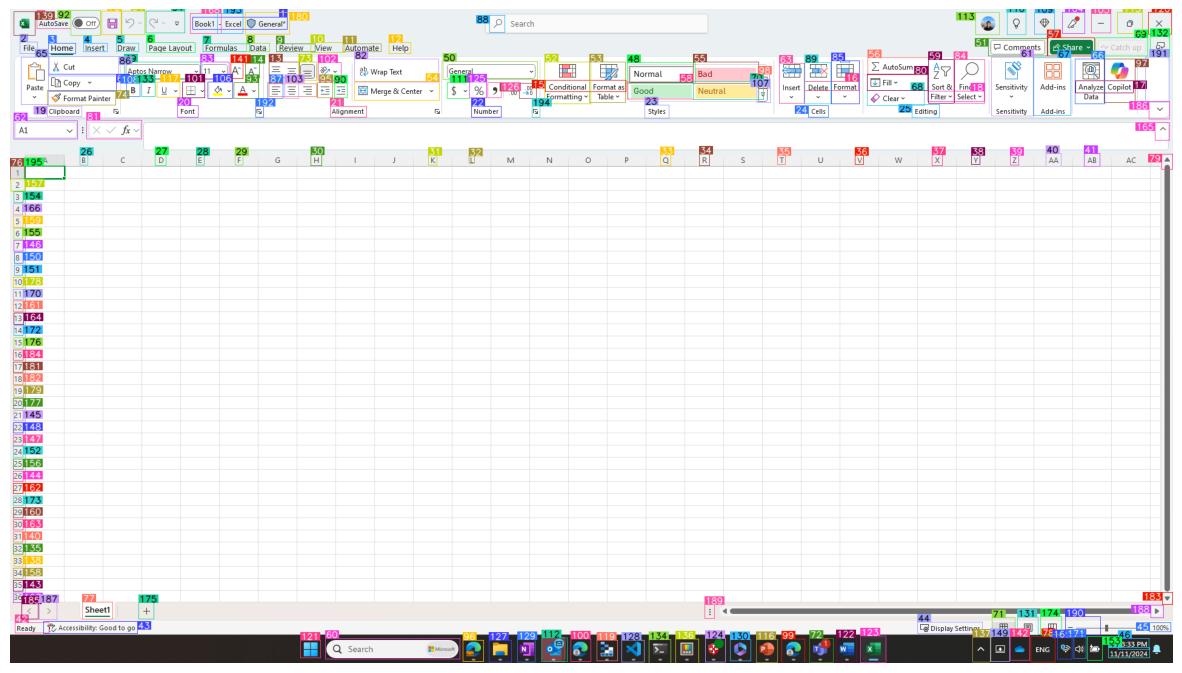

In [10]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [11]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,source,ID
0,text,"[0.02292860858142376, 0.013901760801672935, 0....",False,AutoSave,box_ocr_content_ocr,0
1,text,"[0.15685252845287323, 0.012048192322254181, 0....",False,Book1 - Excel General*,box_ocr_content_ocr,1
2,text,"[0.00885878037661314, 0.05004633963108063, 0.0...",False,File,box_ocr_content_ocr,2
3,text,"[0.03282959759235382, 0.05189990624785423, 0.0...",False,Home,box_ocr_content_ocr,3
4,text,"[0.0630536749958992, 0.052826691418886185, 0.0...",False,Insert,box_ocr_content_ocr,4
...,...,...,...,...,...,...
191,icon,"[0.9762990474700928, 0.0739055648446083, 0.996...",True,unanswerable,box_yolo_content_yolo,191
192,icon,"[0.21119704842567444, 0.14866754412651062, 0.2...",True,A simple profile picture or profile icon.,box_yolo_content_yolo,192
193,icon,"[0.17867043614387512, 0.006980785168707371, 0....",True,Excel,box_yolo_content_yolo,193
194,icon,"[0.4487318694591522, 0.14855234324932098, 0.45...",True,A simple profile picture or profile icon.,box_yolo_content_yolo,194


In [12]:
parsed_content_list

[{'type': 'text',
  'bbox': [0.02292860858142376,
   0.013901760801672935,
   0.052110474556684494,
   0.029657090082764626],
  'interactivity': False,
  'content': 'AutoSave',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.15685252845287323,
   0.012048192322254181,
   0.2381448596715927,
   0.030583873391151428],
  'interactivity': False,
  'content': 'Book1 - Excel General*',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.00885878037661314,
   0.05004633963108063,
   0.023449713364243507,
   0.06765523552894592],
  'interactivity': False,
  'content': 'File',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.03282959759235382,
   0.05189990624785423,
   0.05627931281924248,
   0.06765523552894592],
  'interactivity': False,
  'content': 'Home',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.0630536749958992,
   0.052826691418886185,
   0.08337675780057907,
   0.06580166518688202],
  'interactivity': False,
